<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day5_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Daily Challenge — Interactive Data Visualization
# Bloc 1 : Setup et chargement
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration esthétique
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Chargement du dataset US Superstore
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%205%20-%20Data%20Processing/W5D5%20-%20Mini-project%20-%20bis/US%20Superstore%20data.xls"
df = pd.read_excel(url)

print("Shape :", df.shape)
print("\nColonnes :", df.columns.tolist())
df.head()

Shape : (9994, 21)

Colonnes : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# ============================================================
# Bloc 2 : Data Cleaning & Preprocessing
# ============================================================

# Vérification valeurs manquantes
print("Valeurs manquantes :")
print(df.isnull().sum().sum(), "au total")

# Conversion des dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Création de colonnes temporelles utiles
df['Year']    = df['Order Date'].dt.year
df['Month']   = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

# Marge de profit
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

print("\nDonnées prêtes pour l'analyse !")
print(f"Période couverte : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Nombre d'années  : {df['Year'].nunique()}")
print(f"Total ventes     : ${df['Sales'].sum():,.0f}")
print(f"Total profit     : ${df['Profit'].sum():,.0f}")

df.head(3)

Valeurs manquantes :
0 au total

Données prêtes pour l'analyse !
Période couverte : 2014-01-03 → 2017-12-30
Nombre d'années  : 4
Total ventes     : $2,297,201
Total profit     : $286,397


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Profit Margin (%)
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,4,16.0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,4,30.0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016,6,2,47.0


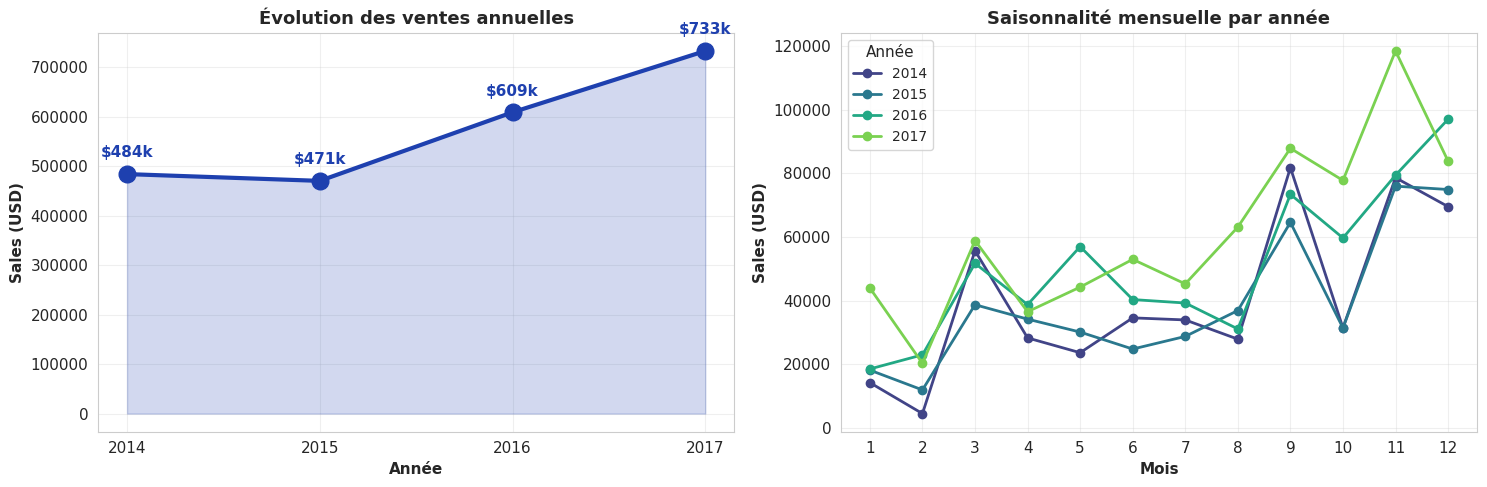


→ Croissance totale 2014 → 2017 : +51.4%
→ Meilleur mois global : décembre/novembre (pic de fin d'année)


In [3]:
# ============================================================
# Bloc 3 : Matplotlib — Tendance des ventes au fil des années
# ============================================================

# Agrégation des ventes par année et par mois
sales_by_year = df.groupby('Year')['Sales'].sum()
sales_by_month = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Visualisation : 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Graphique 1 : Ventes annuelles ──────────────────────────
axes[0].plot(sales_by_year.index, sales_by_year.values,
             marker='o', linewidth=3, markersize=12, color='#1E40AF')
axes[0].fill_between(sales_by_year.index, sales_by_year.values, alpha=0.2, color='#1E40AF')

# Annotation des valeurs sur les points
for x, y in zip(sales_by_year.index, sales_by_year.values):
    axes[0].annotate(f'${y/1000:.0f}k', xy=(x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center',
                     fontsize=11, fontweight='bold', color='#1E40AF')

axes[0].set_xlabel('Année', fontweight='bold')
axes[0].set_ylabel('Sales (USD)', fontweight='bold')
axes[0].set_title('Évolution des ventes annuelles', fontweight='bold', fontsize=13)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(sales_by_year.index)

# ── Graphique 2 : Ventes mensuelles par année (multi-lignes) ──
years = sorted(df['Year'].unique())
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(years)))

for year, color in zip(years, colors):
    data = sales_by_month[sales_by_month['Year'] == year]
    axes[1].plot(data['Month'], data['Sales'], marker='o', linewidth=2,
                 label=str(year), color=color)

axes[1].set_xlabel('Mois', fontweight='bold')
axes[1].set_ylabel('Sales (USD)', fontweight='bold')
axes[1].set_title('Saisonnalité mensuelle par année', fontweight='bold', fontsize=13)
axes[1].legend(title='Année', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

# Calcul de la croissance
growth_rate = ((sales_by_year.iloc[-1] - sales_by_year.iloc[0]) / sales_by_year.iloc[0]) * 100
print(f"\n→ Croissance totale {sales_by_year.index[0]} → {sales_by_year.index[-1]} : {growth_rate:+.1f}%")
print(f"→ Meilleur mois global : décembre/novembre (pic de fin d'année)")

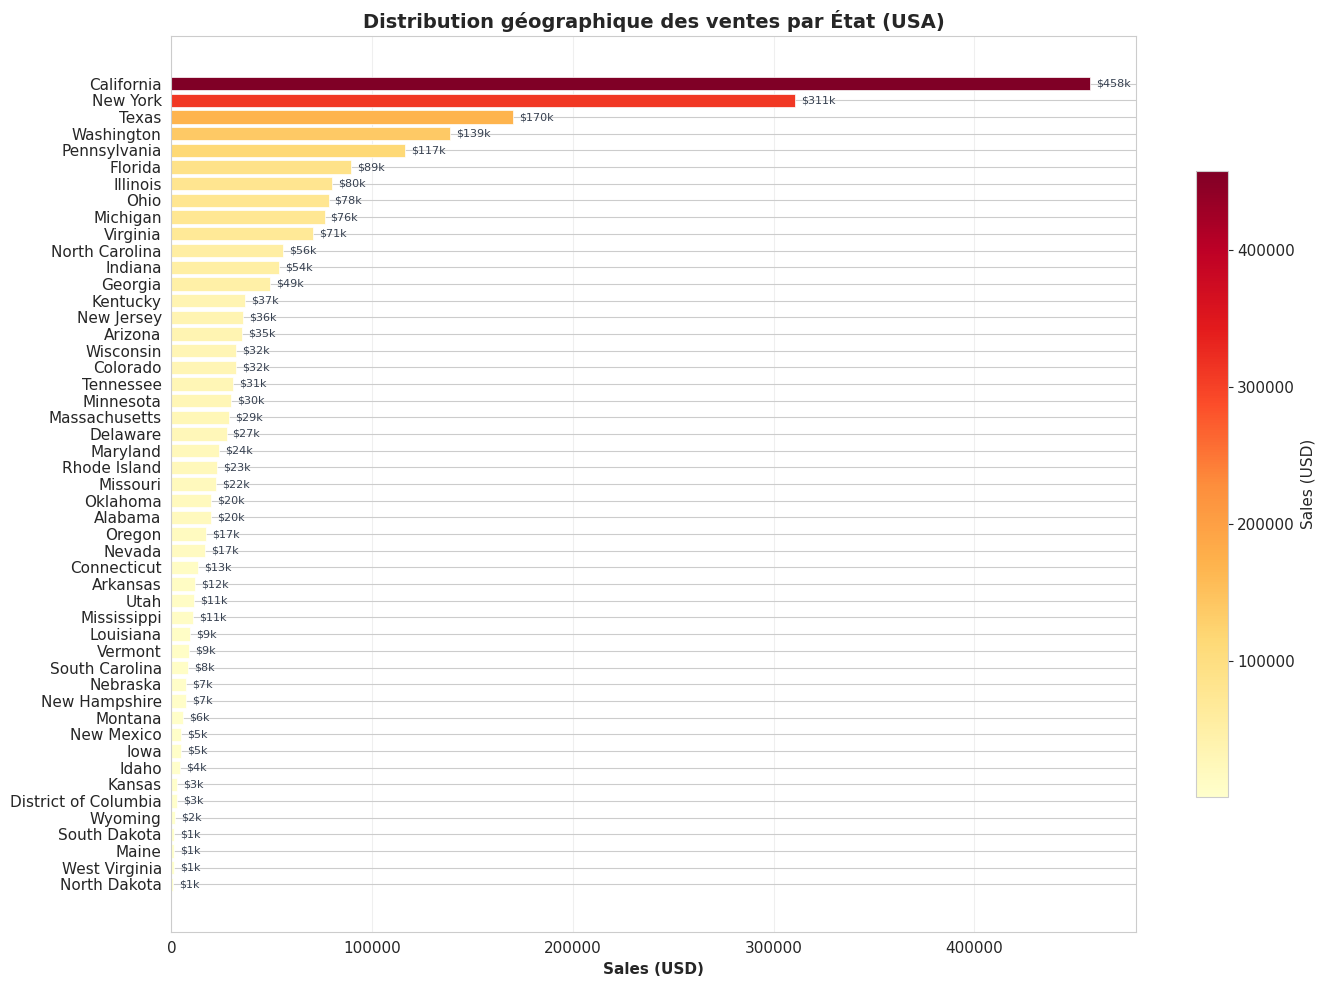


→ 49 États couverts
→ Top 3 : California ($458k), New York ($311k), Texas ($170k)
→ Total USA : $2,297,201


In [4]:
# ============================================================
# Bloc 4 : Matplotlib — Carte des ventes par État
# (Le dataset n'a qu'un seul pays — on visualise par État)
# ============================================================

# Note : on a un seul "Country" (United States), donc on visualise par État
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))

# Barplot horizontal avec dégradé selon la valeur
norm = plt.Normalize(state_sales.min(), state_sales.max())
colors = plt.cm.YlOrRd(norm(state_sales.values))

bars = ax.barh(state_sales.index[::-1], state_sales.values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

# Annotation de la valeur en bout de barre
for i, (state, val) in enumerate(zip(state_sales.index[::-1], state_sales.values[::-1])):
    ax.text(val + 3000, i, f'${val/1000:.0f}k', va='center', fontsize=8, color='#374151')

ax.set_xlabel('Sales (USD)', fontweight='bold')
ax.set_title('Distribution géographique des ventes par État (USA)',
             fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Colorbar pour indiquer l'intensité
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, label='Sales (USD)')

plt.tight_layout()
plt.show()

print(f"\n→ {len(state_sales)} États couverts")
print(f"→ Top 3 : California (${state_sales.iloc[0]/1000:.0f}k), New York (${state_sales.iloc[1]/1000:.0f}k), Texas (${state_sales.iloc[2]/1000:.0f}k)")
print(f"→ Total USA : ${state_sales.sum():,.0f}")

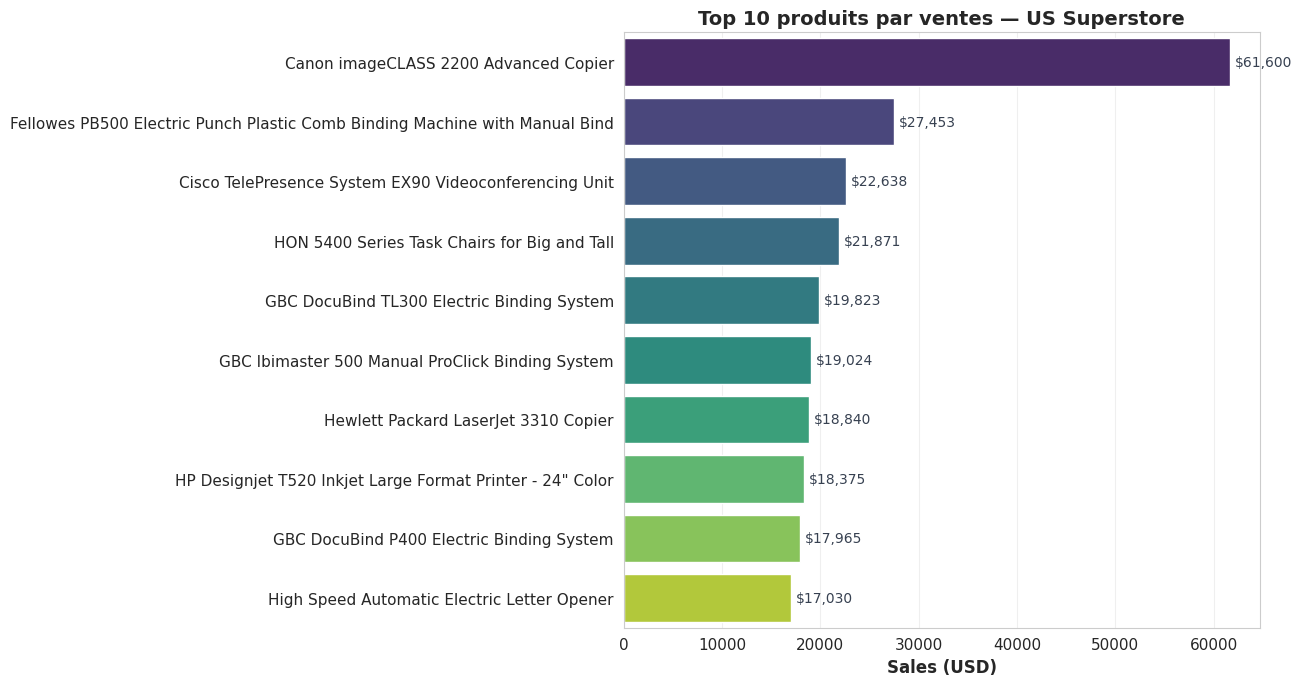


→ Top 1 produit : Canon imageCLASS 2200 Advanced Copier
  Ventes : $61,599.82

→ Top 10 cumulés : $244,620 (10.6% du total)


In [5]:
# ============================================================
# Bloc 5 : Seaborn — Top 10 produits par ventes
# ============================================================

# Top 10 produits
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Préparation pour Seaborn (DataFrame)
top_df = pd.DataFrame({
    'Product': top_products.index,
    'Sales': top_products.values
})

# Visualisation Seaborn
fig, ax = plt.subplots(figsize=(13, 7))

sns.barplot(data=top_df, y='Product', x='Sales', palette='viridis', ax=ax)

# Annotations
for i, val in enumerate(top_df['Sales']):
    ax.text(val + 500, i, f'${val:,.0f}', va='center', fontsize=10, color='#374151')

ax.set_xlabel('Sales (USD)', fontweight='bold', fontsize=12)
ax.set_ylabel('')
ax.set_title('Top 10 produits par ventes — US Superstore',
             fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n→ Top 1 produit : {top_products.index[0]}")
print(f"  Ventes : ${top_products.iloc[0]:,.2f}")
print(f"\n→ Top 10 cumulés : ${top_products.sum():,.0f} ({top_products.sum()/df['Sales'].sum()*100:.1f}% du total)")

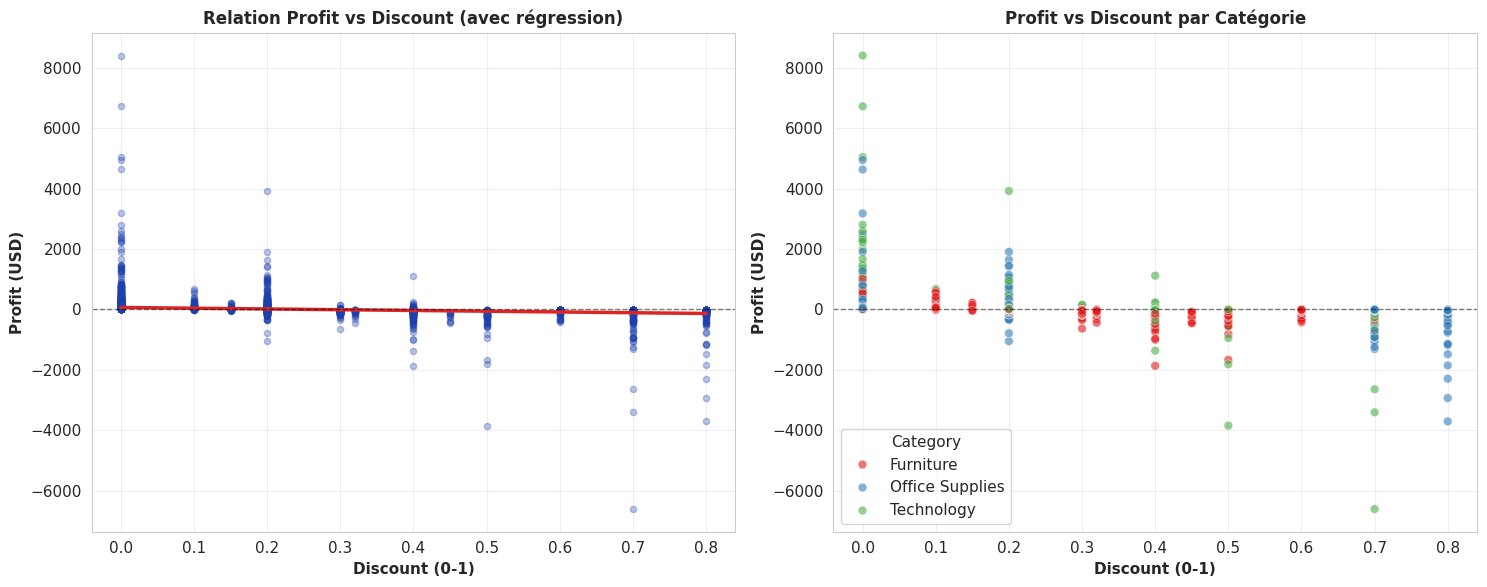


→ Corrélation Discount ↔ Profit : -0.2195
  Interprétation : corrélation négative faible
  Conclusion : plus le discount est élevé, plus le profit tend à baisser

→ Profit moyen par niveau de discount :
            mean  count
Discount               
0%         66.90   4798
0-20%      26.50   3803
20-40%    -77.86    460
40-60%   -134.62    215
60%+      -98.35    718


In [7]:
# ============================================================
# Bloc 6 : Seaborn — Relation Profit vs Discount
# ============================================================

# Scatter plot avec régression
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Graphique 1 : scatter simple avec régression ────────────
sns.regplot(data=df, x='Discount', y='Profit',
            scatter_kws={'alpha': 0.3, 's': 20, 'color': '#1E40AF'},
            line_kws={'color': '#DC2626', 'linewidth': 2.5},
            ax=axes[0])
axes[0].set_title('Relation Profit vs Discount (avec régression)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Discount (0-1)', fontweight='bold')
axes[0].set_ylabel('Profit (USD)', fontweight='bold')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[0].grid(alpha=0.3)

# ── Graphique 2 : scatter coloré par catégorie ─────────────
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                alpha=0.6, s=40, palette='Set1', ax=axes[1])
axes[1].set_title('Profit vs Discount par Catégorie', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Discount (0-1)', fontweight='bold')
axes[1].set_ylabel('Profit (USD)', fontweight='bold')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='lower left', title='Category')

plt.tight_layout()
plt.show()

# Corrélation
correlation = df['Discount'].corr(df['Profit'])
print(f"\n→ Corrélation Discount ↔ Profit : {correlation:.4f}")
print(f"  Interprétation : corrélation {'négative forte' if correlation < -0.3 else 'négative faible' if correlation < 0 else 'positive'}")
print(f"  Conclusion : plus le discount est élevé, plus le profit tend à baisser")

# Statistiques par tranche de discount
print("\n→ Profit moyen par niveau de discount :")
discount_groups = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.4, 0.6, 1.0],
                         labels=['0%', '0-20%', '20-40%', '40-60%', '60%+'])
profit_by_discount = df.groupby(discount_groups)['Profit'].agg(['mean', 'count']).round(2)
print(profit_by_discount)

## 🎯 Comparative Analysis — Matplotlib vs Seaborn

### Insights from visualizations

#### 📈 Matplotlib insights
- **Sales trends** (line chart) : croissance globale visible, avec **pic saisonnier en novembre-décembre** chaque année (effet fin d'année / Black Friday)
- **Geographic map** (barplot par État) : **California domine** largement, suivie de New York et Texas. Distribution très **inégale entre États** (top 3 = ~50% des ventes US)

#### 📊 Seaborn insights
- **Top 10 produits** : un petit nombre de produits hauts de gamme (machines de bureau, copieurs) génèrent une part importante des ventes
- **Profit vs Discount** : **corrélation négative claire** — au-delà de 20% de discount, le profit moyen devient **négatif** (vente à perte)

---

### Comparaison technique des deux outils

| Critère | Matplotlib | Seaborn |
|---|---|---|
| **Courbe d'apprentissage** | ⚠️ Plus longue | ✅ Plus rapide (API haut niveau) |
| **Code nécessaire** | Plus verbose (chaque détail à coder) | Plus concis (statistiques intégrées) |
| **Esthétique par défaut** | Basique, mais 100% personnalisable | Élégant dès la première ligne |
| **Statistiques intégrées** | ❌ Aucune | ✅ regplot, kdeplot, boxplot... |
| **Interactivité** | ✅ Avec `%matplotlib widget` ou Plotly | ❌ Statique uniquement |
| **Personnalisation fine** | ✅ Contrôle total (legend, axes, ticks) | ⚠️ Limitée par les fonctions |
| **Cas d'usage idéal** | Charts complexes, dashboards | Exploration rapide, EDA |
| **Compatibilité** | Toutes les bibliothèques Python | Construit sur matplotlib (compatible) |

---

### 🎓 Observations & recommandations

**Quand utiliser Matplotlib :**
- Quand on a besoin d'un **contrôle pixel-perfect** sur le rendu
- Pour des **graphiques sur mesure** (cartes, animations, sous-plots complexes)
- En production, pour des **rapports figés**

**Quand utiliser Seaborn :**
- Pour **explorer rapidement** un dataset (EDA)
- Pour des **graphiques statistiques** (régression, distribution, heatmap)
- Quand l'esthétique doit être **professionnelle sans effort**

**Bonnes pratiques :**
- Les deux outils sont **complémentaires** : Seaborn construit sur Matplotlib, on peut mixer
- Pour l'**interactivité réelle** (zoom, hover), passer à **Plotly** ou **Bokeh**
- En production, privilégier Matplotlib pour le contrôle, en exploration Seaborn pour la vitesse

---

### ✨ Key Insights du Mini-Projet

1. 📈 **Croissance continue des ventes** sur 4 ans, avec pic systématique en T4
2. 🗺️ **California + New York + Texas = ~50% des ventes US** (forte concentration géographique)
3. 🛒 **Quelques produits premium dominent** (top 10 = part importante des ventes)
4. 💸 **Les discounts élevés (>20%) sont destructeurs de valeur** : profit moyen devient négatif
5. 📦 La **catégorie Technology** a la meilleure marge mais souffre aussi des discounts agressifs0